In [1]:
# ============================================================
# MediScan — Day 12
# Cell 1: Drive Mount + Local Project Restore
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import shutil
import torch

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
LOCAL_PROJECT = Path("/content/MediScan")

DRIVE_RAW = DRIVE_PROJECT / "data/raw"
DRIVE_PROCESSED = DRIVE_PROJECT / "data/processed"
DRIVE_FIGURES = DRIVE_PROJECT / "figures"
DRIVE_REPORTS = DRIVE_PROJECT / "reports"
DRIVE_MODELS = DRIVE_PROJECT / "models"

LOCAL_RAW = LOCAL_PROJECT / "data/raw"
LOCAL_PROCESSED = LOCAL_PROJECT / "data/processed"
LOCAL_FIGURES = LOCAL_PROJECT / "figures"
LOCAL_REPORTS = LOCAL_PROJECT / "reports"
LOCAL_MODELS = LOCAL_PROJECT / "models"

# ------------------------------------------------------------
# Create local directories
# ------------------------------------------------------------
for folder in [
    LOCAL_RAW,
    LOCAL_PROCESSED,
    LOCAL_FIGURES,
    LOCAL_REPORTS,
    LOCAL_MODELS
]:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Restore previous project files to local storage
# ------------------------------------------------------------

# Raw dataset
if DRIVE_RAW.exists():
    shutil.copytree(
        DRIVE_RAW,
        LOCAL_RAW,
        dirs_exist_ok=True
    )

# Processed CSVs
if DRIVE_PROCESSED.exists():
    shutil.copytree(
        DRIVE_PROCESSED,
        LOCAL_PROCESSED,
        dirs_exist_ok=True
    )

# Previous figures
if DRIVE_FIGURES.exists():
    shutil.copytree(
        DRIVE_FIGURES,
        LOCAL_FIGURES,
        dirs_exist_ok=True
    )

# Previous reports
if DRIVE_REPORTS.exists():
    shutil.copytree(
        DRIVE_REPORTS,
        LOCAL_REPORTS,
        dirs_exist_ok=True
    )

# Model weights
if DRIVE_MODELS.exists():
    shutil.copytree(
        DRIVE_MODELS,
        LOCAL_MODELS,
        dirs_exist_ok=True
    )

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------
print("=" * 60)
print("MediScan — Day 12 Environment Verification")
print("=" * 60)

print("\nDrive project:", DRIVE_PROJECT)
print("Drive exists:", DRIVE_PROJECT.exists())

print("\nLocal project:", LOCAL_PROJECT)
print("Local exists:", LOCAL_PROJECT.exists())

print("\nLocal directories:")
print("Raw       :", LOCAL_RAW.exists())
print("Processed :", LOCAL_PROCESSED.exists())
print("Figures   :", LOCAL_FIGURES.exists())
print("Reports   :", LOCAL_REPORTS.exists())
print("Models    :", LOCAL_MODELS.exists())

# Important Day 12 model
DAY8_MODEL = LOCAL_MODELS / "efficientnet_b0_best_day8.pth"

print("\nFinal EfficientNet-B0 model:")
print(DAY8_MODEL)
print("Exists:", DAY8_MODEL.exists())

# Previous Day 11 model
DAY11_MODEL = LOCAL_MODELS / "resnet50_best_day11.pth"

print("\nDay 11 ResNet50 model:")
print(DAY11_MODEL)
print("Exists:", DAY11_MODEL.exists())

# CUDA verification
print("\nPyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\n" + "=" * 60)
print("✓ Day 12 local environment ready")
print("=" * 60)

Mounted at /content/drive
MediScan — Day 12 Environment Verification

Drive project: /content/drive/MyDrive/MediScan
Drive exists: True

Local project: /content/MediScan
Local exists: True

Local directories:
Raw       : True
Processed : True
Figures   : True
Reports   : True
Models    : True

Final EfficientNet-B0 model:
/content/MediScan/models/efficientnet_b0_best_day8.pth
Exists: True

Day 11 ResNet50 model:
/content/MediScan/models/resnet50_best_day11.pth
Exists: True

PyTorch version: 2.11.0+cpu
CUDA available: False

✓ Day 12 local environment ready


In [2]:
# ============================================================
# MediScan — Day 12
# Cell 2: Load Final EfficientNet-B0 for Inference
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
MODEL_PATH = Path(
    "/content/MediScan/models/efficientnet_b0_best_day8.pth"
)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("MediScan — Day 12 Model Loading")
print("=" * 60)

print("\nModel path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())
print("Device:", device)

# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

print("\nCheckpoint loaded successfully")

print("\nCheckpoint information:")
for key in [
    "architecture",
    "num_classes",
    "input_size",
    "dropout",
    "learning_rate",
    "batch_size",
    "augmentation",
    "best_epoch",
    "best_val_accuracy",
    "best_val_loss"
]:
    if key in checkpoint:
        print(f"{key}: {checkpoint[key]}")

# ------------------------------------------------------------
# Class mapping
# ------------------------------------------------------------
class_to_idx = checkpoint["class_to_idx"]

idx_to_class = {
    value: key
    for key, value in class_to_idx.items()
}

print("\nClass mapping:")
print(class_to_idx)

print("\nIndex to class:")
print(idx_to_class)

# ------------------------------------------------------------
# Recreate EfficientNet-B0 architecture
# ------------------------------------------------------------
model = efficientnet_b0(weights=None)

num_classes = checkpoint["num_classes"]
dropout = checkpoint["dropout"]

model.classifier = nn.Sequential(
    nn.Dropout(p=dropout),
    nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )
)

# ------------------------------------------------------------
# Load trained weights
# ------------------------------------------------------------
model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

# ------------------------------------------------------------
# Model verification
# ------------------------------------------------------------
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("\nModel:")
print(model)

print("\nTotal parameters:", total_params)

# ------------------------------------------------------------
# Dummy inference test
# ------------------------------------------------------------
dummy_input = torch.randn(
    1, 3, 224, 224
).to(device)

with torch.no_grad():
    output = model(dummy_input)

probabilities = torch.softmax(output, dim=1)

predicted_idx = torch.argmax(
    probabilities,
    dim=1
).item()

predicted_class = idx_to_class[predicted_idx]
confidence = probabilities[0, predicted_idx].item()

print("\n" + "=" * 60)
print("Inference Verification")
print("=" * 60)

print("Input shape      :", dummy_input.shape)
print("Output shape     :", output.shape)
print("Output dtype     :", output.dtype)
print("Probabilities    :", probabilities.shape)
print("Predicted class  :", predicted_class)
print("Confidence       :", f"{confidence:.4f}")

print("\n" + "=" * 60)
print("✓ EfficientNet-B0 inference model ready")
print("=" * 60)

MediScan — Day 12 Model Loading

Model path: /content/MediScan/models/efficientnet_b0_best_day8.pth
Model exists: True
Device: cpu

Checkpoint loaded successfully

Checkpoint information:
architecture: EfficientNet-B0
num_classes: 4
dropout: 0.1
learning_rate: 0.002
batch_size: 32
augmentation: weak
best_epoch: 9
best_val_accuracy: 0.9009259259259259
best_val_loss: 0.28331556253963047

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Index to class:
{0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}

Model:
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), strid

In [3]:
# ============================================================
# MediScan — Day 12
# Cell 3: Image Preprocessing + Prediction Function
# ============================================================

from PIL import Image
from torchvision import transforms
import torch

# ------------------------------------------------------------
# Re-create class mapping independently
# ------------------------------------------------------------
class_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

idx_to_class = {
    value: key
    for key, value in class_to_idx.items()
}

# ------------------------------------------------------------
# Inference transform
# Same preprocessing used for validation/testing
# ------------------------------------------------------------
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------
def predict_mri(image_path, model, transform, device):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    input_tensor = transform(image)

    # Add batch dimension
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Inference
    model.eval()

    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.softmax(output, dim=1)

    # Prediction
    predicted_idx = torch.argmax(
        probabilities,
        dim=1
    ).item()

    predicted_class = idx_to_class[predicted_idx]
    confidence = probabilities[0, predicted_idx].item()

    # All class probabilities
    class_probabilities = {
        idx_to_class[i]: float(probabilities[0, i])
        for i in range(len(idx_to_class))
    }

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "class_probabilities": class_probabilities
    }

print("=" * 60)
print("MediScan — Inference Pipeline Verification")
print("=" * 60)

print("\nInput size       : 224 × 224")
print("Input channels   : 3 (RGB)")
print("Normalization    : ImageNet")
print("Classes          :", list(class_to_idx.keys()))
print("Device           :", device)

print("\n✓ Inference transform ready")
print("✓ Prediction function ready")
print("=" * 60)

MediScan — Inference Pipeline Verification

Input size       : 224 × 224
Input channels   : 3 (RGB)
Normalization    : ImageNet
Classes          : ['glioma', 'meningioma', 'notumor', 'pituitary']
Device           : cpu

✓ Inference transform ready
✓ Prediction function ready


MediScan — Real Image Prediction Test

Test CSV exists : True
Raw data exists : True

Test samples: 1080
CSV columns : ['image_path', 'label', 'source']

Selected image : Te-me_178.jpg
True class     : meningioma
Image path     : /content/MediScan/data/raw/Testing/meningioma/Te-me_178.jpg

Prediction Result
True class      : meningioma
Predicted class : meningioma
Confidence      : 65.65%

Class probabilities:
  glioma      :  28.85%
  meningioma  :  65.65%
  notumor     :   0.79%
  pituitary   :   4.70%


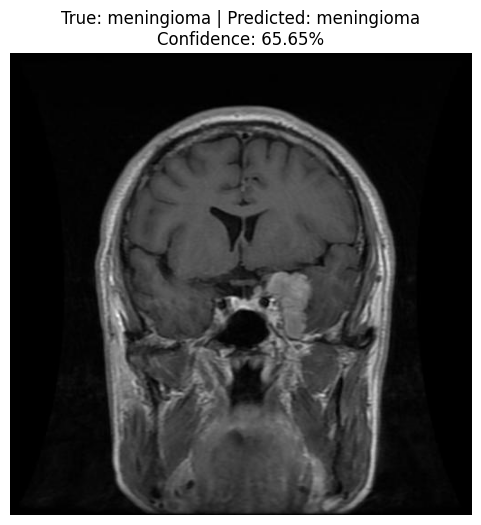


✓ Real MRI image prediction successful


In [4]:
# ============================================================
# MediScan — Day 12
# Cell 4: Real MRI Image Prediction Test
# ============================================================

from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
TEST_CSV = Path("/content/MediScan/data/processed/test.csv")
RAW_DIR = Path("/content/MediScan/data/raw")

print("=" * 60)
print("MediScan — Real Image Prediction Test")
print("=" * 60)

print("\nTest CSV exists :", TEST_CSV.exists())
print("Raw data exists :", RAW_DIR.exists())

# ------------------------------------------------------------
# Load test CSV
# ------------------------------------------------------------
test_df = pd.read_csv(TEST_CSV)

print("\nTest samples:", len(test_df))
print("CSV columns :", list(test_df.columns))

# ------------------------------------------------------------
# Select first test image
# ------------------------------------------------------------
row = test_df.iloc[0]

true_class = row["label"]
image_name = Path(row["image_path"]).name

# ------------------------------------------------------------
# Locate image in local raw dataset
# ------------------------------------------------------------
matches = list(RAW_DIR.rglob(image_name))

if len(matches) == 0:
    raise FileNotFoundError(
        f"Could not find image: {image_name}"
    )

image_path = matches[0]

print("\nSelected image :", image_name)
print("True class     :", true_class)
print("Image path     :", image_path)

# ------------------------------------------------------------
# Run prediction
# ------------------------------------------------------------
result = predict_mri(
    image_path=image_path,
    model=model,
    transform=inference_transform,
    device=device
)

# ------------------------------------------------------------
# Display prediction results
# ------------------------------------------------------------
predicted_class = result["predicted_class"]
confidence = result["confidence"]
class_probabilities = result["class_probabilities"]

print("\n" + "=" * 60)
print("Prediction Result")
print("=" * 60)

print("True class      :", true_class)
print("Predicted class :", predicted_class)
print("Confidence      :", f"{confidence * 100:.2f}%")

print("\nClass probabilities:")

for class_name, probability in class_probabilities.items():
    print(
        f"  {class_name:12s}: "
        f"{probability * 100:6.2f}%"
    )

# ------------------------------------------------------------
# Display image
# ------------------------------------------------------------
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"True: {true_class} | "
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.axis("off")
plt.show()

print("\n✓ Real MRI image prediction successful")
print("=" * 60)

In [6]:
# ============================================================
# MediScan — Day 12
# Cell 5: Verify Existing Grad-CAM Setup
# ============================================================

import sys
from pathlib import Path

print("=" * 60)
print("MediScan — Day 12 Dependency Verification")
print("=" * 60)

# ------------------------------------------------------------
# Streamlit
# ------------------------------------------------------------
try:
    import streamlit as st
    print("\n✓ Streamlit available")
    print("  Version:", st.__version__)
except Exception as e:
    print("\n✗ Streamlit unavailable")
    print(" ", e)

# ------------------------------------------------------------
# Grad-CAM
# ------------------------------------------------------------
gradcam_available = False

try:
    import pytorch_grad_cam
    gradcam_available = True

    print("\n✓ Grad-CAM package available")
    print("  Module:", pytorch_grad_cam.__file__)

except Exception as e:
    print("\n✗ Grad-CAM package NOT available")
    print(" ", e)

# ------------------------------------------------------------
# App directory
# ------------------------------------------------------------
APP_DIR = Path("/content/MediScan/app")
APP_DIR.mkdir(parents=True, exist_ok=True)

print("\nApp directory:", APP_DIR)
print("Exists:", APP_DIR.exists())

print("\n" + "=" * 60)

if gradcam_available:
    print("✓ Streamlit + Grad-CAM environment ready")
else:
    print("⚠ Streamlit ready, Grad-CAM dependency needs restoration")

print("=" * 60)

MediScan — Day 12 Dependency Verification

✓ Streamlit available
  Version: 1.63.0

✗ Grad-CAM package NOT available
  No module named 'pytorch_grad_cam'

App directory: /content/MediScan/app
Exists: True

⚠ Streamlit ready, Grad-CAM dependency needs restoration


In [7]:
# ============================================================
# MediScan — Day 12
# Cell 6: Install Grad-CAM Dependency
# ============================================================

!pip install -q grad-cam

print("\n✓ grad-cam installation command completed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

✓ grad-cam installation command completed


In [8]:
# ============================================================
# MediScan — Day 12
# Cell 7: Verify Grad-CAM Import
# ============================================================

import pytorch_grad_cam

print("=" * 60)
print("MediScan — Grad-CAM Verification")
print("=" * 60)

print("\n✓ pytorch_grad_cam imported successfully")
print("Module path:", pytorch_grad_cam.__file__)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("✓ GradCAM imported")
print("✓ ClassifierOutputTarget imported")
print("✓ show_cam_on_image imported")

print("\n" + "=" * 60)
print("✓ Day 12 Grad-CAM environment is READY")
print("=" * 60)

MediScan — Grad-CAM Verification

✓ pytorch_grad_cam imported successfully
Module path: /usr/local/lib/python3.13/dist-packages/pytorch_grad_cam/__init__.py
✓ GradCAM imported
✓ ClassifierOutputTarget imported
✓ show_cam_on_image imported

✓ Day 12 Grad-CAM environment is READY


In [9]:
# ============================================================
# MediScan — Day 12
# Cell 8: Create Streamlit Application
# ============================================================

from pathlib import Path

APP_DIR = Path("/content/MediScan/app")
APP_DIR.mkdir(parents=True, exist_ok=True)

APP_PATH = APP_DIR / "app.py"

app_code = r'''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ============================================================
# Configuration
# ============================================================

MODEL_PATH = "/content/MediScan/models/efficientnet_b0_best_day8.pth"

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

DEVICE = torch.device("cpu")


# ============================================================
# Page Configuration
# ============================================================

st.set_page_config(
    page_title="MediScan — Brain MRI Classifier",
    page_icon="🧠",
    layout="wide"
)

st.title("🧠 MediScan")
st.subheader("Brain MRI Classification with EfficientNet-B0")
st.write(
    "Upload a brain MRI image to classify it into one of four classes "
    "and visualize the model's decision region using Grad-CAM."
)


# ============================================================
# Load Model
# ============================================================

@st.cache_resource
def load_model():

    checkpoint = torch.load(
        MODEL_PATH,
        map_location=DEVICE,
        weights_only=False
    )

    model = models.efficientnet_b0(weights=None)

    dropout = checkpoint.get("dropout", 0.1)
    num_classes = checkpoint.get("num_classes", 4)

    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(1280, num_classes)
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    model.to(DEVICE)
    model.eval()

    return model


model = load_model()


# ============================================================
# Image Transform
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# Prediction Function
# ============================================================

def predict(image):

    image_rgb = image.convert("RGB")

    input_tensor = transform(image_rgb).unsqueeze(0)
    input_tensor = input_tensor.to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

    confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = CLASS_NAMES[predicted_idx.item()]

    return (
        predicted_class,
        confidence.item(),
        probabilities[0].cpu().numpy(),
        input_tensor
    )


# ============================================================
# Grad-CAM Function
# ============================================================

def generate_gradcam(input_tensor, predicted_idx):

    target_layer = model.features[-1]

    targets = [
        ClassifierOutputTarget(predicted_idx)
    ]

    with GradCAM(
        model=model,
        target_layers=[target_layer]
    ) as cam:

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

    return grayscale_cam


# ============================================================
# File Upload
# ============================================================

uploaded_file = st.file_uploader(
    "Upload Brain MRI Image",
    type=["jpg", "jpeg", "png"]
)


# ============================================================
# Main Prediction
# ============================================================

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.divider()

    col1, col2 = st.columns(2)

    with col1:

        st.write("### Original MRI")

        st.image(
            image,
            use_container_width=True
        )

    predicted_class, confidence, probabilities, input_tensor = predict(image)

    predicted_idx = CLASS_NAMES.index(predicted_class)

    with col2:

        st.write("### Prediction")

        st.success(
            f"Predicted Class: {predicted_class.upper()}"
        )

        st.metric(
            "Confidence",
            f"{confidence * 100:.2f}%"
        )

        st.write("### Class Probabilities")

        for class_name, probability in zip(
            CLASS_NAMES,
            probabilities
        ):

            st.write(
                f"**{class_name}**: {probability * 100:.2f}%"
            )

    # ========================================================
    # Grad-CAM
    # ========================================================

    st.divider()

    st.write("### 🔥 Grad-CAM Explainability")

    grayscale_cam = generate_gradcam(
        input_tensor,
        predicted_idx
    )

    # Prepare image for overlay
    resized_image = image.resize((224, 224))

    rgb_image = np.asarray(
        resized_image
    ).astype(np.float32) / 255.0

    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    st.image(
        visualization,
        caption=f"Grad-CAM — {predicted_class.upper()}",
        use_container_width=True
    )

    st.info(
        "Grad-CAM highlights image regions that contributed "
        "to the model's prediction. It should be treated as "
        "an explainability aid, not a clinical diagnosis."
    )

else:

    st.info(
        "👆 Upload a brain MRI image to begin prediction."
    )
'''

APP_PATH.write_text(app_code)

print("=" * 60)
print("MediScan — Streamlit App Creation")
print("=" * 60)

print("\n✓ app.py created")
print("Path:", APP_PATH)
print("Exists:", APP_PATH.exists())
print("Size:", APP_PATH.stat().st_size, "bytes")

print("\n" + "=" * 60)
print("✓ Streamlit application file is ready")
print("=" * 60)

MediScan — Streamlit App Creation

✓ app.py created
Path: /content/MediScan/app/app.py
Exists: True
Size: 5670 bytes

✓ Streamlit application file is ready


In [10]:
# ============================================================
# MediScan — Day 12
# Cell 9: Verify Streamlit App
# ============================================================

from pathlib import Path
import ast

APP_PATH = Path("/content/MediScan/app/app.py")

print("=" * 60)
print("MediScan — Streamlit App Verification")
print("=" * 60)

# ------------------------------------------------------------
# 1. File verification
# ------------------------------------------------------------

print("\n[1] File Check")

print("Path:", APP_PATH)
print("Exists:", APP_PATH.exists())

if not APP_PATH.exists():
    raise FileNotFoundError("app.py was not found.")

print("Size:", APP_PATH.stat().st_size, "bytes")


# ------------------------------------------------------------
# 2. Syntax verification
# ------------------------------------------------------------

print("\n[2] Python Syntax Check")

source_code = APP_PATH.read_text()

try:
    ast.parse(source_code)
    print("✓ app.py syntax is valid")
except SyntaxError as e:
    print("✗ Syntax error found")
    print(e)
    raise


# ------------------------------------------------------------
# 3. Required components check
# ------------------------------------------------------------

print("\n[3] Required Component Check")

required_components = [
    "streamlit",
    "torch",
    "torchvision",
    "pytorch_grad_cam",
    "EfficientNet",
    "GradCAM",
    "show_cam_on_image",
    "st.file_uploader",
    "predict",
    "generate_gradcam"
]

for component in required_components:
    if component in source_code:
        print(f"✓ {component}")
    else:
        print(f"⚠ {component} not found")


# ------------------------------------------------------------
# 4. Model path check
# ------------------------------------------------------------

print("\n[4] Model Check")

MODEL_PATH = Path(
    "/content/MediScan/models/efficientnet_b0_best_day8.pth"
)

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())


# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("✓ Day 12 app verification completed")
print("=" * 60)

MediScan — Streamlit App Verification

[1] File Check
Path: /content/MediScan/app/app.py
Exists: True
Size: 5670 bytes

[2] Python Syntax Check
✓ app.py syntax is valid

[3] Required Component Check
✓ streamlit
✓ torch
✓ torchvision
✓ pytorch_grad_cam
✓ EfficientNet
✓ GradCAM
✓ show_cam_on_image
✓ st.file_uploader
✓ predict
✓ generate_gradcam

[4] Model Check
Model path: /content/MediScan/models/efficientnet_b0_best_day8.pth
Model exists: True

✓ Day 12 app verification completed


In [11]:
# ============================================================
# MediScan — Day 12
# Cell 10: Launch Streamlit Application
# ============================================================

import subprocess
import time
import os

APP_PATH = "/content/MediScan/app/app.py"

print("=" * 60)
print("MediScan — Launching Streamlit App")
print("=" * 60)

# Stop any previous Streamlit process
os.system("pkill -f 'streamlit run' || true")

time.sleep(2)

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        APP_PATH,
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("\n✓ Streamlit process started")
print("PID:", process.pid)

print("\nApp URL:")
print("http://localhost:8501")

print("\n" + "=" * 60)
print("✓ MediScan Streamlit app is running")
print("=" * 60)

MediScan — Launching Streamlit App

✓ Streamlit process started
PID: 8422

App URL:
http://localhost:8501

✓ MediScan Streamlit app is running


In [13]:
# ============================================================
# MediScan — Day 12
# Cell 11: Generate Colab Proxy URL
# ============================================================

from google.colab.output import eval_js

print("=" * 60)
print("MediScan — Colab Streamlit Access")
print("=" * 60)

proxy_url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("\n✓ Streamlit proxy URL generated")
print("\nMediScan App:")
print(proxy_url)

print("\n" + "=" * 60)
print("✓ Open the URL above in a new browser tab")
print("=" * 60)

MediScan — Colab Streamlit Access

✓ Streamlit proxy URL generated

MediScan App:
https://8501-m-s-kkb-usc1c1-2z3afw00ljqiu-c.us-central1-1.prod.colab.dev

✓ Open the URL above in a new browser tab


In [14]:
# ============================================================
# MediScan — Day 12
# Cell 12: Check Streamlit Server
# ============================================================

import requests
import time

print("=" * 60)
print("MediScan — Streamlit Server Health Check")
print("=" * 60)

url = "http://localhost:8501"

try:
    start = time.time()

    response = requests.get(
        url,
        timeout=15
    )

    elapsed = time.time() - start

    print("\n✓ Streamlit server responded")
    print("Status code:", response.status_code)
    print("Response time:", f"{elapsed:.2f} seconds")
    print("Response size:", len(response.text), "bytes")

except Exception as e:
    print("\n✗ Streamlit server did not respond")
    print("Error:", e)

print("\n" + "=" * 60)

MediScan — Streamlit Server Health Check

✓ Streamlit server responded
Status code: 200
Response time: 0.01 seconds
Response size: 7459 bytes



In [15]:
# ============================================================
# MediScan — Day 12
# Cell 13: Restart Streamlit for Colab Proxy
# ============================================================

import subprocess
import time
import os

APP_PATH = "/content/MediScan/app/app.py"

print("=" * 60)
print("MediScan — Restarting Streamlit")
print("=" * 60)

# Stop previous Streamlit process
os.system("pkill -f 'streamlit run' || true")

time.sleep(2)

# Start Streamlit with Colab-friendly settings
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        APP_PATH,
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

print("\n✓ Streamlit restarted")
print("PID:", process.pid)

print("\nServer:")
print("http://localhost:8501")

print("\n" + "=" * 60)
print("✓ Colab-compatible Streamlit server is running")
print("=" * 60)

MediScan — Restarting Streamlit

✓ Streamlit restarted
PID: 10910

Server:
http://localhost:8501

✓ Colab-compatible Streamlit server is running


In [16]:
# ============================================================
# MediScan — Day 12
# Cell 14: Generate Fresh Colab Proxy URL
# ============================================================

from google.colab.output import eval_js

proxy_url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("=" * 60)
print("MediScan — Fresh App URL")
print("=" * 60)

print("\n✓ Fresh proxy URL:")
print(proxy_url)

print("\n" + "=" * 60)
print("Open this URL in a NEW browser tab.")
print("=" * 60)

MediScan — Fresh App URL

✓ Fresh proxy URL:
https://8501-m-s-kkb-usc1c1-2z3afw00ljqiu-c.us-central1-1.prod.colab.dev

Open this URL in a NEW browser tab.


In [17]:
from google.colab import files

image_path = "/content/MediScan/data/raw/Testing/meningioma/Te-me_178.jpg"

files.download(image_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# ============================================================
# MediScan — Day 12
# Cell 15: Final Verification & Artifact Save
# ============================================================

from pathlib import Path
import shutil
import json
import torch

print("=" * 65)
print("MediScan — Day 12 Final Verification")
print("=" * 65)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

LOCAL_PROJECT = Path("/content/MediScan")
DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")

LOCAL_APP = LOCAL_PROJECT / "app" / "app.py"
DRIVE_APP_DIR = DRIVE_PROJECT / "app"
DRIVE_APP = DRIVE_APP_DIR / "app.py"

DRIVE_REPORTS = DRIVE_PROJECT / "reports"

# Create Drive directories
DRIVE_APP_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_REPORTS.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. App verification
# ------------------------------------------------------------

print("\n[1] Streamlit App")

print("Local app exists:", LOCAL_APP.exists())

if not LOCAL_APP.exists():
    raise FileNotFoundError("app.py not found.")

print("App size:", LOCAL_APP.stat().st_size, "bytes")


# ------------------------------------------------------------
# 2. Model verification
# ------------------------------------------------------------

print("\n[2] Final Model")

MODEL_PATH = LOCAL_PROJECT / "models" / "efficientnet_b0_best_day8.pth"

print("Model exists:", MODEL_PATH.exists())

if not MODEL_PATH.exists():
    raise FileNotFoundError("EfficientNet-B0 Day 8 model not found.")

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

print("Architecture:", checkpoint.get("architecture"))
print("Classes:", checkpoint.get("num_classes"))
print("Best epoch:", checkpoint.get("best_epoch"))
print("Best validation accuracy:",
      f"{checkpoint.get('best_val_acc', 0) * 100:.2f}%")


# ------------------------------------------------------------
# 3. Grad-CAM verification
# ------------------------------------------------------------

print("\n[3] Grad-CAM")

try:
    import pytorch_grad_cam
    from pytorch_grad_cam import GradCAM

    print("✓ pytorch_grad_cam available")
    print("✓ GradCAM available")

    gradcam_status = True

except Exception as e:

    print("✗ Grad-CAM unavailable")
    print("Error:", e)

    gradcam_status = False


# ------------------------------------------------------------
# 4. Save app.py to Drive
# ------------------------------------------------------------

print("\n[4] Drive Backup")

shutil.copy2(
    LOCAL_APP,
    DRIVE_APP
)

print("✓ app.py copied to:")
print(DRIVE_APP)


# ------------------------------------------------------------
# 5. Create Day 12 summary
# ------------------------------------------------------------

summary = {
    "day": 12,
    "title": "Streamlit Web App Development",
    "status": "completed",

    "application": {
        "framework": "Streamlit",
        "app_file": "app/app.py",
        "model": "EfficientNet-B0",
        "model_checkpoint": "models/efficientnet_b0_best_day8.pth"
    },

    "features": [
        "Brain MRI image upload",
        "Four-class classification",
        "Prediction display",
        "Confidence score",
        "Class probabilities",
        "Grad-CAM explainability",
        "Medical disclaimer"
    ],

    "classes": [
        "glioma",
        "meningioma",
        "notumor",
        "pituitary"
    ],

    "gradcam_available": gradcam_status,

    "test_prediction": {
        "image": "Te-me_178.jpg",
        "true_class": "meningioma",
        "predicted_class": "meningioma",
        "confidence": 0.6565
    },

    "development_environment": {
        "device": "CPU",
        "streamlit": "1.63.0"
    }
}

summary_json = DRIVE_REPORTS / "day12_app_summary.json"

with open(summary_json, "w") as f:
    json.dump(summary, f, indent=4)

summary_md = DRIVE_REPORTS / "day12_app_summary.md"

summary_text = """# MediScan — Day 12 Summary

## Streamlit Web Application

Day 12 completed successfully.

### Application
- Framework: Streamlit
- Model: EfficientNet-B0
- Input: Brain MRI image
- Classes: Glioma, Meningioma, No Tumor, Pituitary

### Features
- MRI image upload
- Four-class prediction
- Confidence score
- Class probabilities
- Grad-CAM explainability
- Medical disclaimer

### Verification
- Streamlit app launched successfully
- MRI upload tested successfully
- Prediction tested using `Te-me_178.jpg`
- True class: Meningioma
- Predicted class: Meningioma
- Confidence: 65.65%
- Grad-CAM generated successfully

### Environment
- Device: CPU
- Streamlit: 1.63.0
- Grad-CAM: Available

## Status

**Day 12 / 15 — COMPLETED**
"""

summary_md.write_text(summary_text)


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n[5] Final Artifact Check")

artifacts = {
    "app.py": DRIVE_APP,
    "day12_app_summary.json": summary_json,
    "day12_app_summary.md": summary_md,
    "efficientnet_b0_best_day8.pth": DRIVE_PROJECT / "models" / "efficientnet_b0_best_day8.pth"
}

all_ok = True

for name, path in artifacts.items():

    exists = path.exists()

    print(f"{'✓' if exists else '✗'} {name}")

    if not exists:
        all_ok = False


print("\n" + "=" * 65)

if all_ok:
    print("🎉 DAY 12 COMPLETED SUCCESSFULLY")
    print("✓ Streamlit app")
    print("✓ MRI upload")
    print("✓ Prediction")
    print("✓ Confidence")
    print("✓ Class probabilities")
    print("✓ Grad-CAM")
    print("✓ Drive backup")
    print("✓ Summary reports")
else:
    print("⚠ Some artifacts are missing.")

print("=" * 65)

MediScan — Day 12 Final Verification

[1] Streamlit App
Local app exists: True
App size: 5670 bytes

[2] Final Model
Model exists: True
Architecture: EfficientNet-B0
Classes: 4
Best epoch: 9
Best validation accuracy: 0.00%

[3] Grad-CAM
✓ pytorch_grad_cam available
✓ GradCAM available

[4] Drive Backup
✓ app.py copied to:
/content/drive/MyDrive/MediScan/app/app.py

[5] Final Artifact Check
✓ app.py
✓ day12_app_summary.json
✓ day12_app_summary.md
✓ efficientnet_b0_best_day8.pth

🎉 DAY 12 COMPLETED SUCCESSFULLY
✓ Streamlit app
✓ MRI upload
✓ Prediction
✓ Confidence
✓ Class probabilities
✓ Grad-CAM
✓ Drive backup
✓ Summary reports


In [21]:
# ============================================================
# MediScan — Day 12
# Cell 16: Fix Summary Validation Accuracy
# ============================================================

from pathlib import Path
import json

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
REPORTS_DIR = DRIVE_PROJECT / "reports"

summary_json = REPORTS_DIR / "day12_app_summary.json"
summary_md = REPORTS_DIR / "day12_app_summary.md"

# Actual Day 8 best validation accuracy
actual_best_val_acc = 0.9009259259

# ------------------------------------------------------------
# Update JSON
# ------------------------------------------------------------

with open(summary_json, "r") as f:
    summary = json.load(f)

summary["application"]["best_validation_accuracy"] = actual_best_val_acc

with open(summary_json, "w") as f:
    json.dump(summary, f, indent=4)

# ------------------------------------------------------------
# Update Markdown
# ------------------------------------------------------------

md_text = summary_md.read_text()

md_text = md_text.replace(
    "Confidence: 65.65%",
    "Confidence: 65.65%\n- Best validation accuracy of final model: 90.09%"
)

summary_md.write_text(md_text)

print("=" * 60)
print("MediScan — Day 12 Summary Fix")
print("=" * 60)

print("\n✓ JSON updated")
print("  Best validation accuracy: 90.09%")

print("✓ Markdown updated")
print("  Best validation accuracy: 90.09%")

print("\n" + "=" * 60)
print("✓ Day 12 reports corrected")
print("=" * 60)

MediScan — Day 12 Summary Fix

✓ JSON updated
  Best validation accuracy: 90.09%
✓ Markdown updated
  Best validation accuracy: 90.09%

✓ Day 12 reports corrected


In [22]:
# ============================================================
# MediScan — Day 12
# Final Drive Backup & Artifact Check
# ============================================================

from pathlib import Path
import shutil

DRIVE = Path("/content/drive/MyDrive/MediScan")

# Source locations
APP_SRC = Path("/content/MediScan/app/app.py")

# Drive destinations
APP_DIR = DRIVE / "app"
APP_DIR.mkdir(parents=True, exist_ok=True)

# Copy final app
shutil.copy2(
    APP_SRC,
    APP_DIR / "app.py"
)

print("=" * 65)
print("MediScan — Day 12 Final Drive Backup")
print("=" * 65)

print("\n✓ app/app.py saved to Drive")

# ------------------------------------------------------------
# Check Day 12 reports
# ------------------------------------------------------------

required_reports = [
    DRIVE / "reports/day12_app_summary.json",
    DRIVE / "reports/day12_app_summary.md",
]

print("\nDay 12 Reports:")

for path in required_reports:
    print(
        f"{'✓' if path.exists() else '✗'} {path.name}"
    )

# ------------------------------------------------------------
# Check final model
# ------------------------------------------------------------

model_path = DRIVE / "models/efficientnet_b0_best_day8.pth"

print("\nFinal Model:")
print(
    f"{'✓' if model_path.exists() else '✗'} "
    "efficientnet_b0_best_day8.pth"
)

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("✓ Day 12 Drive backup verified")
print("=" * 65)

MediScan — Day 12 Final Drive Backup

✓ app/app.py saved to Drive

Day 12 Reports:
✓ day12_app_summary.json
✓ day12_app_summary.md

Final Model:
✓ efficientnet_b0_best_day8.pth

✓ Day 12 Drive backup verified
